<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recurrent Neural Networks (RNNs) in Deep Learning

Recurrent Neural Networks (RNNs) are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, speech, time series, or video. Unlike traditional feedforward neural networks, which process each input independently, RNNs have a 'memory' that allows them to use information from previous steps in the sequence to influence the processing of the current step.

### How RNNs Work:

The core idea behind an RNN is its recurrent connection. At each time step `t`, the RNN takes two inputs:

1.  **Current input `x_t`**: The data point at the current step in the sequence.
2.  **Previous hidden state `h_t-1`**: The 'memory' from the previous time step, which encapsulates information about all preceding inputs in the sequence.

These two inputs are combined (e.g., through a weighted sum and an activation function) to produce two outputs:

1.  **Current hidden state `h_t`**: This is the updated 'memory' that is passed to the next time step `t+1`.
2.  **Output `y_t`**: This can be the prediction or result for the current time step. In some architectures, the output might only be generated at the final time step.

This recurrent nature allows RNNs to maintain a context or 'state' that evolves as the network processes the sequence.

### Key Characteristics and Components:

*   **Hidden State (Memory)**: The most crucial component. It's a vector that captures information about the sequence seen so far. It's updated at each time step.
*   **Weights and Biases**: Like other neural networks, RNNs have learnable weights and biases. Crucially, the *same* weights and biases are used across all time steps, enabling the network to learn sequential dependencies rather than treating each step as an independent problem.
*   **Activation Functions**: Non-linear functions (like `tanh` or `ReLU`) are applied to the hidden state and output calculations to introduce non-linearity, allowing the model to learn complex patterns.
*   **Backpropagation Through Time (BPTT)**: This is the training algorithm for RNNs. It's an extension of standard backpropagation, where the error is backpropagated through the unfolded network (representing all time steps) to update the shared weights.

### Types of RNN Architectures (Input/Output Mappings):

RNNs are flexible and can be configured for various sequence-to-sequence tasks:

1.  **One-to-One**: Standard neural network (e.g., image classification).
2.  **One-to-Many**: Single input, multiple outputs (e.g., image captioning, where an image generates a sequence of words).
3.  **Many-to-One**: Multiple inputs, single output (e.g., sentiment analysis, where a sentence generates a single sentiment score).
4.  **Many-to-Many (Sequence-to-Sequence)**:
    *   **Synchronous**: Input sequence length equals output sequence length (e.g., video frame classification, where each frame generates a label).
    *   **Asynchronous (Encoder-Decoder)**: Input and output sequence lengths can differ (e.g., machine translation, where an English sentence is translated into a French sentence of a different length).

### Challenges of Basic RNNs:

While powerful, vanilla RNNs suffer from two major problems:

1.  **Vanishing Gradient Problem**: During BPTT, gradients can become extremely small as they propagate back through many time steps, making it difficult for the network to learn long-term dependencies (i.e., information from early parts of a long sequence might not affect later parts).
2.  **Exploding Gradient Problem**: Conversely, gradients can become extremely large, leading to unstable training and large weight updates that cause the model to diverge.

### Solutions to Challenges (Advanced RNN Architectures):

To address these limitations, more sophisticated RNN architectures have been developed:

*   **Long Short-Term Memory (LSTM) Networks**: LSTMs introduce a 'cell state' and various 'gates' (input, forget, output gates) that regulate the flow of information into and out of the cell state. This mechanism allows LSTMs to effectively learn and remember long-term dependencies, mitigating the vanishing gradient problem.
*   **Gated Recurrent Units (GRUs)**: GRUs are a simpler variant of LSTMs, combining the forget and input gates into an 'update gate' and merging the cell state and hidden state. They offer comparable performance to LSTMs on many tasks but with fewer parameters, making them computationally less expensive.

### Applications of RNNs:

RNNs and their variants (LSTMs, GRUs) are widely used in various deep learning applications:

*   **Natural Language Processing (NLP)**: Machine translation, sentiment analysis, text generation, speech recognition, named entity recognition.
*   **Time Series Prediction**: Stock price forecasting, weather forecasting, demand forecasting.
*   **Video Analysis**: Activity recognition, video captioning.
*   **Generative Models**: Music generation, image generation with sequential elements.

In summary, RNNs are fundamental for processing sequential data, and while basic RNNs face challenges with long-term dependencies, advanced architectures like LSTMs and GRUs have made them indispensable tools in modern deep learning.

#why we need RNN
We need Recurrent Neural Networks (RNNs) primarily because of their ability to process and understand sequential data. Traditional neural networks (like Multi-Layer Perceptrons or CNNs) treat each input as independent. This works well for tasks like image classification where pixels are spatially related but don't inherently follow a sequence over time.

However, many real-world data types have a strong temporal or sequential dependency. Consider these examples:

**Text:** The meaning of a word often depends on the words that came before it. "I am going to the bank" has a different meaning if "bank" is preceded by "river" or "money". RNNs can maintain context across words in a sentence.

**Speech:** Understanding a spoken sentence requires processing a sequence of sound waves where the order and relationships between sounds are crucial.

**Time Series Data:** Stock prices, weather patterns, or sensor readings are all sequences where future values depend on past values. Predicting the next value requires considering the history.

**Video:** Each frame in a video is part of a sequence, and understanding an action requires analyzing how the frames evolve over time.

RNNs address this by having an internal memory (the hidden state) that allows them to remember information from previous steps in a sequence. This 'memory' enables them to learn and leverage temporal dependencies, which is something standard feedforward networks cannot do effectively. Without RNNs (or similar sequence models like LSTMs and GRUs), tasks involving natural language, speech, and time series data would be significantly more challenging or even impossible to solve with deep learning.

## Structure of a Recurrent Neural Network (RNN)

To understand the structure of an RNN, it's helpful to visualize it in two ways:

1.  **As a looped structure**: This highlights its recurrent nature.
2.  **As an unfolded structure**: This shows how information flows over time during processing.

### Looped Structure (Conceptual View)

Conceptually, an RNN looks like a single neural network layer that feeds its output (or a part of it) back into itself as an input for the next step. It consists of:

*   **Input Layer (X)**: Receives the input for the current time step (e.g., a word embedding).
*   **Hidden Layer (H)**: This is the core of the RNN. It takes two inputs:
    *   The current input `X_t`.
    *   The hidden state `H_t-1` from the previous time step.
    It then computes the new hidden state `H_t`.
*   **Output Layer (Y)**: Generates the output `Y_t` for the current time step based on the current hidden state `H_t`. (Note: in some architectures, the output is only generated at the final step).

### Unfolded Structure (Detailed View)

When we 'unroll' or 'unfold' an RNN over time, it looks like a deep feedforward network where each layer represents a time step. This view is crucial for understanding how BPTT (Backpropagation Through Time) works.

Let's break down the components at each time step `t`:

1.  **Input Vector (`x_t`)**: This is the data point for the current time step. For example, if processing text, `x_t` could be a vector representation (embedding) of the `t`-th word in a sentence.

2.  **Hidden State Vector (`h_t`)**: This is the 'memory' or 'context' of the RNN at time `t`. It's calculated based on the current input `x_t` and the hidden state from the previous time step `h_t-1`:
    `h_t = f(W_xh * x_t + W_hh * h_{t-1} + b_h)`
    Where:
    *   `W_xh`: Weight matrix for input to hidden state connections.
    *   `W_hh`: Weight matrix for recurrent hidden state to hidden state connections.
    *   `b_h`: Bias vector for the hidden layer.
    *   `f`: An activation function (e.g., `tanh` or `ReLU`).
    **Key Point**: The weight matrices (`W_xh`, `W_hh`) and bias vector (`b_h`) are *shared* across all time steps. This is what allows the RNN to learn temporal patterns.

3.  **Output Vector (`y_t`)**: This is the prediction or result generated at time `t`. It's typically calculated based on the current hidden state `h_t`:
    `y_t = g(W_hy * h_t + b_y)`
    Where:
    *   `W_hy`: Weight matrix for hidden state to output connections.
    *   `b_y`: Bias vector for the output layer.
    *   `g`: An activation function, often `softmax` for classification tasks or linear for regression.
    Like the hidden layer weights, `W_hy` and `b_y` are also shared across time steps.

### Visual Representation:

Imagine a sequence of inputs `x_0, x_1, x_2, ..., x_n`.

*   At `t=0`: `h_0 = f(W_xh * x_0 + b_h)` (assuming `h_{-1}` is initialized to zero).
*   At `t=1`: `h_1 = f(W_xh * x_1 + W_hh * h_0 + b_h)`
*   At `t=2`: `h_2 = f(W_xh * x_2 + W_hh * h_1 + b_h)`
*   And so on.

At each step, an output `y_t` can be generated from `h_t`.

### Summary of Structure:

An RNN's power lies in its ability to loop information back to itself, allowing it to process sequences and maintain an internal state that reflects the history of the sequence. The shared weights across time steps are fundamental to its learning mechanism for sequential data. While the basic structure is simple, it forms the foundation for more complex and effective architectures like LSTMs and GRUs, which introduce 'gates' to better control the flow of information into and out of the hidden state, thereby addressing issues like the vanishing gradient problem.

## Artificial Neural Networks (ANNs) vs. Recurrent Neural Networks (RNNs)

While both Artificial Neural Networks (ANNs), often referred to as Feedforward Neural Networks, and Recurrent Neural Networks (RNNs) are fundamental deep learning architectures, they are designed to handle different types of data and problems. The primary distinction lies in how they process information, particularly concerning sequences.

Here's a detailed comparison:

### 1. Data Type and Processing:

*   **ANNs (Feedforward Neural Networks):**
    *   **Input Data:** Primarily designed for **independent, fixed-size data points**. Each input is treated in isolation, without considering its relationship to previous or subsequent inputs.
    *   **Processing:** Information flows in one direction, from the input layer through one or more hidden layers to the output layer. There are no feedback loops.
    *   **Examples:** Image classification (each image is an independent data point), tabular data analysis, simple pattern recognition where order doesn't matter.

*   **RNNs (Recurrent Neural Networks):**
    *   **Input Data:** Specifically designed for **sequential or time-series data**, where the order and context of elements are crucial. The length of the input sequence can be variable.
    *   **Processing:** Information flows from input to output, but also *recycles* or *recurs* through a hidden state back into the network for the next time step. This internal loop allows RNNs to maintain a 'memory' of past inputs.
    *   **Examples:** Natural Language Processing (text, speech recognition), time series prediction (stock prices, weather), video analysis.

### 2. Memory and Context:

*   **ANNs:**
    *   **Memory:** Have **no explicit memory** of past inputs. Each input is processed as a fresh, new data point. The network's weights and biases are learned based on the entire training set, but individual predictions don't retain information about prior individual inputs.
    *   **Context:** Cannot capture long-range dependencies or context within a sequence.

*   **RNNs:**
    *   **Memory:** Possess an **internal memory** in the form of a 'hidden state' (`h_t`). This hidden state is updated at each time step and carries information from all previous inputs in the sequence. This is their defining characteristic.
    *   **Context:** Excel at capturing contextual information and dependencies across different time steps within a sequence.

### 3. Architecture:

*   **ANNs:**
    *   **Structure:** Consist of an input layer, one or more hidden layers, and an output layer. Neurons in one layer are connected to neurons in the next layer.
    *   **Weights:** Each connection between neurons has a unique weight. Weights are fixed once training is complete.

*   **RNNs:**
    *   **Structure:** Feature a recurrent connection where the output of a hidden layer at time `t` is fed back as an input to the same hidden layer at time `t+1`. They effectively 'unroll' into multiple layers over time, with each layer representing a time step.
    *   **Weights:** Crucially, the **same set of weights** is used across all time steps. This weight sharing is what allows them to learn temporal patterns and makes them suitable for variable-length sequences.

### 4. Training:

*   **ANNs:**
    *   **Algorithm:** Trained using standard backpropagation, where gradients are calculated once for each input.
    *   **Challenges:** Generally straightforward to train, provided the data is well-suited for feedforward processing.

*   **RNNs:**
    *   **Algorithm:** Trained using Backpropagation Through Time (BPTT), which essentially involves unfolding the recurrent network into a deep feedforward network and then applying backpropagation. This is computationally more intensive.
    *   **Challenges:** Prone to **vanishing and exploding gradient problems**, especially with long sequences, making it difficult to learn long-term dependencies. Advanced architectures like LSTMs and GRUs were developed to mitigate these issues.

### 5. Use Cases:

*   **ANNs:**
    *   Image classification
    *   Handwritten digit recognition (when treating digits as independent images)
    *   Regression problems with independent features
    *   Categorization tasks where order doesn't matter

*   **RNNs:**
    *   Machine translation
    *   Speech recognition
    *   Text generation
    *   Sentiment analysis
    *   Time series forecasting
    *   Video captioning

### Summary Table:

| Feature           | Artificial Neural Network (ANN)               | Recurrent Neural Network (RNN)                      |
| :---------------- | :-------------------------------------------- | :-------------------------------------------------- |
| **Data Type**     | Independent, fixed-size data                  | Sequential, time-series data (variable length)      |
| **Memory**        | No explicit memory                            | Internal memory (hidden state)                      |
| **Context**       | Processes inputs independently                | Captures context and temporal dependencies          |
| **Information Flow**| Unidirectional (input -> output)              | Recurrent (input -> hidden -> output, hidden -> hidden for next step) |
| **Weight Sharing**| Each connection has unique weights            | Weights are shared across all time steps            |
| **Training**      | Standard Backpropagation                      | Backpropagation Through Time (BPTT)                 |
| **Challenges**    | Less prone to gradient issues with independent data | Vanishing/Exploding gradients (for vanilla RNNs)  |
| **Primary Use**   | Classification, regression for independent data | NLP, time series, speech, video                     |

In essence, if your data has a sequential nature where the order of elements is significant for understanding, an RNN (or its variants) is the appropriate choice. If each data point can be understood and processed independently, an ANN is typically sufficient.

## RNN Code Example with TensorFlow/Keras

This example demonstrates a simple RNN built with TensorFlow/Keras to predict the next number in a sequence. While a basic RNN might not be the most efficient for this specific task (LSTMs or GRUs would handle longer sequences better), it serves as a good illustration of the core concept.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Generate some sequential data
# Let's create a simple sequence like [0, 1, 2, 3, 4, 5, ...] and try to predict the next number.

def generate_sequence_data(num_sequences, seq_length):
    X, y = [], []
    for _ in range(num_sequences):
        # Start with a random number to make diverse sequences
        start_num = np.random.randint(0, 10)
        sequence = [start_num + i for i in range(seq_length + 1)]

        # Input is the first 'seq_length' numbers
        X.append(sequence[:-1])
        # Output is the next number in the sequence
        y.append(sequence[-1])

    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    # Reshape X for RNN input: (samples, timesteps, features)
    # Here, each timestep has 1 feature (the number itself)
    X = X.reshape(num_sequences, seq_length, 1)

    return X, y

# Parameters for data generation
num_sequences = 1000
seq_length = 5 # Predict the 6th number based on the previous 5

X_train, y_train = generate_sequence_data(num_sequences, seq_length)
X_test, y_test = generate_sequence_data(100, seq_length)

print(f"X_train shape: {X_train.shape}") # (samples, timesteps, features)
print(f"y_train shape: {y_train.shape}") # (samples, target)

print("\nSample input (X_train[0]):")
print(X_train[0].flatten())
print("Sample target (y_train[0]):")
print(y_train[0])

X_train shape: (1000, 5, 1)
y_train shape: (1000,)

Sample input (X_train[0]):
[3 4 5 6 7]
Sample target (y_train[0]):
8


### Model Definition

We'll define a simple Sequential model with a `SimpleRNN` layer followed by a `Dense` (output) layer.

In [2]:
# 2. Build the RNN Model
model = Sequential([
    # SimpleRNN is the basic recurrent layer
    # 'units' is the dimensionality of the output space (hidden state size)
    # 'input_shape' specifies (timesteps, features)
    SimpleRNN(units=32, activation='relu', input_shape=(seq_length, 1)),

    # A Dense layer to output the final prediction (a single number)
    Dense(units=1)
])

# 3. Compile the model
# Using 'mean_squared_error' as it's a regression task (predicting a number)
# 'adam' is a popular optimizer
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

The model will be trained on the generated sequences. The `epochs` define how many times the model sees the entire dataset.

In [3]:
# 4. Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 190.7329 - val_loss: 140.3176
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 104.1235 - val_loss: 67.4772
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38.0500 - val_loss: 9.7399
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3107 - val_loss: 1.6592
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3734 - val_loss: 1.1880
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8697 - val_loss: 0.6459
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4486 - val_loss: 0.3247
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1903 - val_loss: 0.1299
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0711 - val_loss: 0.0588
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0322 - val_loss: 0.0346
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0221 - val_loss: 0.0268
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0177

### Making Predictions

Let's see how the trained RNN predicts on a new, unseen sequence.

In [4]:
# 5. Make predictions on test data
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Mean Squared Error): {loss:.4f}")

# Predict on a new sequence
new_sequence = np.array([10, 11, 12, 13, 14])
# Reshape for the model: (1, timesteps, features)
new_sequence = new_sequence.reshape(1, seq_length, 1)

prediction = model.predict(new_sequence)[0][0]
print(f"\nInput sequence: {new_sequence.flatten()}")
print(f"Predicted next number: {prediction:.2f}")
print(f"Actual next number (based on pattern): {new_sequence.flatten()[-1] + 1}")

Test Loss (Mean Squared Error): 0.0049
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step

Input sequence: [10 11 12 13 14]
Predicted next number: 15.07
Actual next number (based on pattern): 15


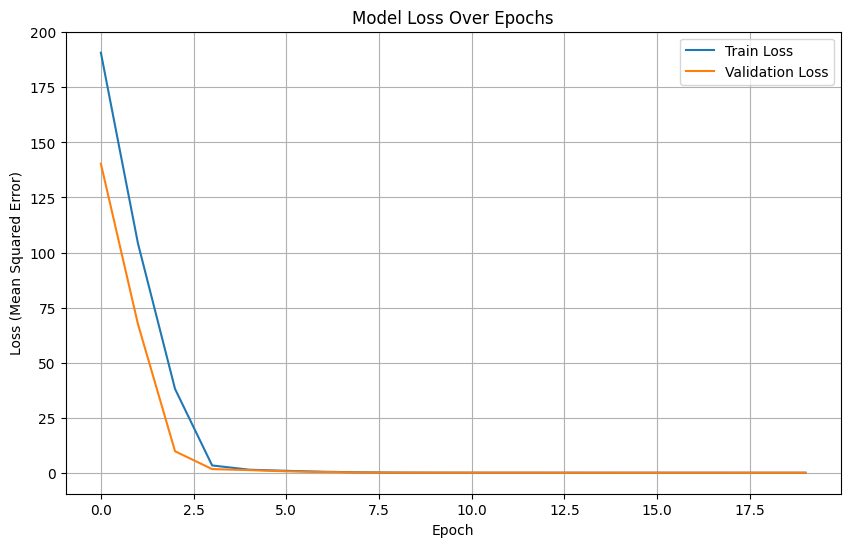

In [5]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()